In [17]:
!pip install protobuf==3.20.0 --no-dependencies

In [18]:
import os

# --- 1. Define Paths for Kaggle Input Directory ---
# This is the path Kaggle creates for your dataset.
# The dataset name is 'karyogram-cv-camp' and the top folder inside is '2025_Karyogram_CV_Camp'
base_path = '/kaggle/input/karyogram-cv-camp/2025_Karyogram_CV_Camp'
images_path = os.path.join(base_path, '24_chromosomes_object', 'images')
annotations_path = os.path.join(base_path, '24_chromosomes_object', 'annotations')
train_file = os.path.join(base_path, 'train.txt')

# --- 2. Run Verification Checks ---
print("--- Verifying Dataset Paths ---")

# Check if the main folders exist
print(f"Base folder exists: {os.path.exists(base_path)} -> {base_path}")
print(f"Images folder exists: {os.path.exists(images_path)}")
print(f"Annotations folder exists: {os.path.exists(annotations_path)}")
print(f"train.txt file exists: {os.path.exists(train_file)}")

# --- 3. Preview Contents ---
if os.path.exists(train_file):
    print("\n--- Previewing train.txt ---")
    try:
        with open(train_file, 'r') as f:
            lines = [f.readline().strip() for _ in range(5)]
        print("First 5 image names:", lines)
        print(" Verification successful! You can now proceed to preprocessing.")
    except Exception as e:
        print(f" Error reading train.txt: {e}")
else:
    print("\n Verification failed. Please check your dataset name and paths.")

--- Verifying Dataset Paths ---
Base folder exists: True -> /kaggle/input/karyogram-cv-camp/2025_Karyogram_CV_Camp
Images folder exists: True
Annotations folder exists: True
train.txt file exists: True

--- Previewing train.txt ---
First 5 image names: ['103064', '103071', '103072', '103081', '103082']
 Verification successful! You can now proceed to preprocessing.


In [4]:
import os
import numpy as np
import tensorflow as tf
import cv2
import xml.etree.ElementTree as ET
from tqdm import tqdm
import json
from collections import Counter
# Re-define Paths and Constants (As they were in your previous cell)
BASE_PATH = '/kaggle/input/karyogram-cv-camp/2025_Karyogram_CV_Camp'
MODEL_PATH = "/kaggle/input/model97-2/tensorflow2/v6_97/1/re_tune_best_model_var_lr.h5"
JSON_PATH = "/kaggle/input/chromosome-class-names/class_names.json"
TRAIN_FILE_LIST = os.path.join(BASE_PATH, 'train.txt')
IMAGE_SIZE = (128, 128)
MIN_CROP_DIMENSION = 10
BATCH_SIZE = 64 

# Load Class Names
with open(JSON_PATH, 'r') as f:
    CLASS_NAMES = json.load(f)
class_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

# --- 2. Train Set Data Generator (Original, but without tqdm) ---
def train_prediction_generator():
    images_path = os.path.join(BASE_PATH, "24_chromosomes_object", "images")
    annotations_path = os.path.join(BASE_PATH, "24_chromosomes_object", "annotations")
    
    with open(TRAIN_FILE_LIST, 'r') as f:
        train_names = [line.strip() for line in f]
    
    for image_name in train_names:
        # ... (same file reading and XML parsing logic as before) ...
        # (This section is omitted here for brevity, assume it's the same)
        image_path = os.path.join(images_path, image_name + ".jpg")
        xml_path = os.path.join(annotations_path, image_name + ".xml")

        if not os.path.exists(image_path) or not os.path.exists(xml_path): continue
        image = cv2.imread(image_path)
        if image is None: continue

        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
        except ET.ParseError:
            continue

        for i, member in enumerate(root.findall('object')):
            try:
                label_name = member.find('name').text.strip().upper()
                if label_name not in class_to_index: continue
                label_index = class_to_index[label_name]
                
                bndbox = member.find('bndbox')
                xmin, ymin = int(bndbox.find('xmin').text), int(bndbox.find('ymin').text)
                xmax, ymax = int(bndbox.find('xmax').text), int(bndbox.find('ymax').text)
            except Exception:
                continue

            crop = image[ymin:ymax, xmin:xmax]
            if crop.size == 0: continue
            h, w, _ = crop.shape
            if h < MIN_CROP_DIMENSION or w < MIN_CROP_DIMENSION: continue

            resized_crop = cv2.resize(crop, IMAGE_SIZE)
            resized_crop_rescaled = resized_crop.astype("float32") / 255.0
            
            crop_id = f"{image_name}_crop_{i}" 
            
            # YIELD ONLY TENSOR DATA (Image and Label)
            yield resized_crop_rescaled, label_index
            

# --- NEW COMBINED SECTION: Prediction, Extraction, and Metadata Collection ---

print("--- 3. Prediction and Data Collection (Fixing the Interruption Issue) ---")

# 3a. Create the tf.data.Dataset for prediction (Image and Label)
train_ds = tf.data.Dataset.from_generator(
    train_prediction_generator,
    output_signature=(
         tf.TensorSpec(shape=(128, 128, 3), dtype=tf.float32),
         tf.TensorSpec(shape=(), dtype=tf.int32)
    ))

# 3b. Batch the dataset
train_ds_batched = train_ds.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

# Load your trained model
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded.")

# --- Perform Prediction and Collect True Labels/IDs in ONE Go ---

y_true_list = []
y_pred_list = []
crop_ids_list = []
images_path = os.path.join(BASE_PATH, "24_chromosomes_object", "images")
annotations_path = os.path.join(BASE_PATH, "24_chromosomes_object", "annotations")

# Re-run the generator to collect IDs/True Labels concurrently with prediction
# This ensures perfect alignment and processes everything in one pass

print("Making predictions and collecting data...")

# Re-initialize the generator to iterate over all samples and get IDs
# We use the original file list to estimate the total count for the progress bar
with open(TRAIN_FILE_LIST, 'r') as f:
    train_names = [line.strip() for line in f]
total_images = len(train_names) # Approx. 18,000 images * 23 crops/image

# Since we don't know the exact sample count, we iterate over the batches
# The correct way to guarantee all samples are processed is to use model.predict
# and then manually match the IDs in a separate generator run.
# HOWEVER, since the previous method failed, we'll revert to a simpler CPU loop for safety.

print("Switching to manual iteration for reliable data extraction...")
# This loop iterates through the prediction results batch by batch
for x_batch, y_true_batch in tqdm(train_ds_batched, desc="Predicting and collecting"):
    
    # 1. Predict on the batch
    y_pred_probs_batch = model.predict(x_batch, verbose=0)
    y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
    
    # 2. Collect True Labels
    y_true_list.append(y_true_batch.numpy())
    
    # 3. Collect Predictions
    y_pred_list.append(y_pred_batch)

# Concatenate all batches
y_true_indices = np.concatenate(y_true_list)
y_pred_indices = np.concatenate(y_pred_list)


# --- Re-run the generator once more to get the CROP IDs (Safest Alignment) ---
# NOTE: This is slow, but guarantees correct alignment after successful prediction.
print("Collecting unique crop identifiers (IDs)...")
crop_ids_list = []
for image_name in tqdm(train_names, desc="Collecting IDs"):
    image_path = os.path.join(images_path, image_name + ".jpg")
    xml_path = os.path.join(annotations_path, image_name + ".xml")
    
    # Skip if files don't exist (matching generator logic)
    if not os.path.exists(image_path) or not os.path.exists(xml_path): continue
    
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except ET.ParseError: continue

    for i, member in enumerate(root.findall('object')):
        # Check label validity (matching generator logic)
        try:
            label_name = member.find('name').text.strip().upper()
            if label_name not in class_to_index: continue
            
            bndbox = member.find('bndbox')
            # Check bounding box validity (matching generator logic)
            xmin, ymin = int(bndbox.find('xmin').text), int(bndbox.find('ymin').text)
            xmax, ymax = int(bndbox.find('xmax').text), int(bndbox.find('ymax').text)
        except Exception: continue

        crop_id = f"{image_name}_crop_{i}"
        crop_ids_list.append(crop_id)


crop_ids_decoded = np.array(crop_ids_list)


# --- 4. Identify Misclassified Samples (Final Step) ---

misclassified_mask = (y_true_indices != y_pred_indices)
# misclassified_indices_list = np.where(misclassified_mask)[0] # This line is not needed

# -------------------- START OF FIX --------------------

# 1. Determine the length of the successfully processed samples (the shorter array)
min_length = len(y_true_indices) 

# 2. Crop the ID array to match the prediction length (This resolves the IndexError)
aligned_crop_ids = crop_ids_decoded[:min_length] 

# -------------------- END OF FIX --------------------


# Extract the metadata for the misclassified crops
misclassified_true_indices = y_true_indices[misclassified_mask]
misclassified_pred_indices = y_pred_indices[misclassified_mask]

# CHANGE: Use the new aligned_crop_ids array here instead of the full crop_ids_decoded
misclassified_crop_ids = aligned_crop_ids[misclassified_mask] 

# -------------------- Verification Printout --------------------

print(f"\nTotal training samples processed (Aligned): {len(y_true_indices)}")
print(f"Total misclassified samples found in the training set: {len(misclassified_crop_ids)}")

2025-11-28 08:30:02.552157: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764318602.849030      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764318602.900325      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


--- 3. Prediction and Data Collection (Fixing the Interruption Issue) ---


I0000 00:00:1764318617.045475      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model loaded.
Making predictions and collecting data...
Switching to manual iteration for reliable data extraction...


Predicting and collecting: 0it [00:00, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1764318621.437748     115 service.cc:148] XLA service 0x7d3f34017c90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764318621.438392     115 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764318621.915621     115 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1764318624.537567     115 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Predicting and collecting: 2689it [04:42,  9.53it/s]



Total training samples processed (Aligned): 172055
Total misclassified samples found in the training set: 2787


In [19]:
import numpy as np
from collections import defaultdict
import os

# --- 1. Data Structures Initialization ---

# Dictionary to store lists of crop IDs that were CORRECTLY classified for each class.
# Key: Class Index (0-23)
# Value: List of crop ID strings (e.g., '103064_crop_0')
correctly_matched_ids = defaultdict(list)

# List to store metadata for all MISCLASSIFIED samples.
# Each element is a tuple: (crop_id, true_index, pred_index)
misclassified_data = []

# --- 2. Iterate and Populate Index ---

# Ensure all arrays are aligned to the minimum length processed during prediction
min_length = min(len(y_true_indices), len(y_pred_indices), len(crop_ids_decoded))

# Align the arrays if necessary (this should only crop the end of crop_ids_decoded)
aligned_y_true = y_true_indices[:min_length]
aligned_y_pred = y_pred_indices[:min_length]
aligned_crop_ids = crop_ids_decoded[:min_length]

print(f"\n--- Starting Indexing of {min_length} samples ---")

for i in range(min_length):
    crop_id = aligned_crop_ids[i]
    y_true = aligned_y_true[i]
    y_pred = aligned_y_pred[i]
    
    if y_true == y_pred:
        # Sample was correctly classified (MATCHED)
        correctly_matched_ids[y_true].append(crop_id)
    else:
        # Sample was misclassified (MISMATCHED)
        misclassified_data.append((crop_id, y_true, y_pred))

# --- 3. Summary and Verification ---

total_correct = sum(len(ids) for ids in correctly_matched_ids.values())
total_misclassified = len(misclassified_data)
total_indexed = total_correct + total_misclassified

print("Indexing complete.")
print(f"Total samples indexed: {total_indexed}")
print(f"Total correctly classified samples: {total_correct}")
print(f"Total misclassified samples detected: {total_misclassified}")

# Verification of sample balance for reference lookup
print("\nCorrectly Classified Samples per Class (Reference Pool Size):")
for idx, name in enumerate(CLASS_NAMES):
    count = len(correctly_matched_ids[idx])
    print(f"  {name}: {count} samples")
    if count < 5:
         # Warn if a class has too few samples for a visual reference of 5
         print(f"    [WARNING: Only {count} reference samples available. Consider reducing the reference count in Phase 2.]")

# Set up the two lists to store user decisions in the next phase
keep_list = []
discard_list = []

print("\nPhase 1 complete. The data is structured and ready for interactive inspection.")


--- Starting Indexing of 172055 samples ---
Indexing complete.
Total samples indexed: 172055
Total correctly classified samples: 169268
Total misclassified samples detected: 2787

Correctly Classified Samples per Class (Reference Pool Size):
  A1: 7419 samples
  A2: 7330 samples
  A3: 7351 samples
  B4: 7325 samples
  B5: 7291 samples
  C10: 7305 samples
  C11: 7378 samples
  C12: 7394 samples
  C6: 7297 samples
  C7: 7410 samples
  C8: 7286 samples
  C9: 7369 samples
  D13: 7373 samples
  D14: 7409 samples
  D15: 7365 samples
  E16: 7392 samples
  E17: 7405 samples
  E18: 7362 samples
  F19: 7404 samples
  F20: 7388 samples
  G21: 7436 samples
  G22: 7367 samples
  X: 5330 samples
  Y: 1882 samples

Phase 1 complete. The data is structured and ready for interactive inspection.


In [8]:
import pickle
import os

CHECKPOINT_FILE = 'manual_review_checkpoint.pkl'

def save_checkpoint(k_list, d_list, c_list):
    """Saves the current state of the decision lists to a file."""
    checkpoint_data = {
        'keep': k_list,
        'discard': d_list,
        'confused': c_list
    }
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump(checkpoint_data, f)
    print(f"\n[CHECKPOINT SAVED] Progress saved to {CHECKPOINT_FILE}.")
    print(f"Current Counts: Keep={len(k_list)}, Discard={len(d_list)}, Confused={len(c_list)}")


def load_checkpoint():
    """Loads the last saved state of the decision lists."""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'rb') as f:
            checkpoint_data = pickle.load(f)
        print(f"[CHECKPOINT LOADED] Restoring progress from {CHECKPOINT_FILE}.")
        print(f"Loaded Counts: Keep={len(checkpoint_data['keep'])}, Discard={len(checkpoint_data['discard'])}, Confused={len(checkpoint_data['confused'])}")
        return checkpoint_data['keep'], checkpoint_data['discard'], checkpoint_data['confused']
    else:
        print("[No Checkpoint Found] Starting lists empty.")
        # Return empty lists if no checkpoint exists
        return [], [], []

# --- Example Usage in Your Notebook ---
# 1. In a fresh cell, initialize the lists by loading the checkpoint:
# keep_list, discard_list, confused_list = load_checkpoint()

# 2. After reviewing a batch, run this cell manually:
# save_checkpoint(keep_list, discard_list, confused_list)

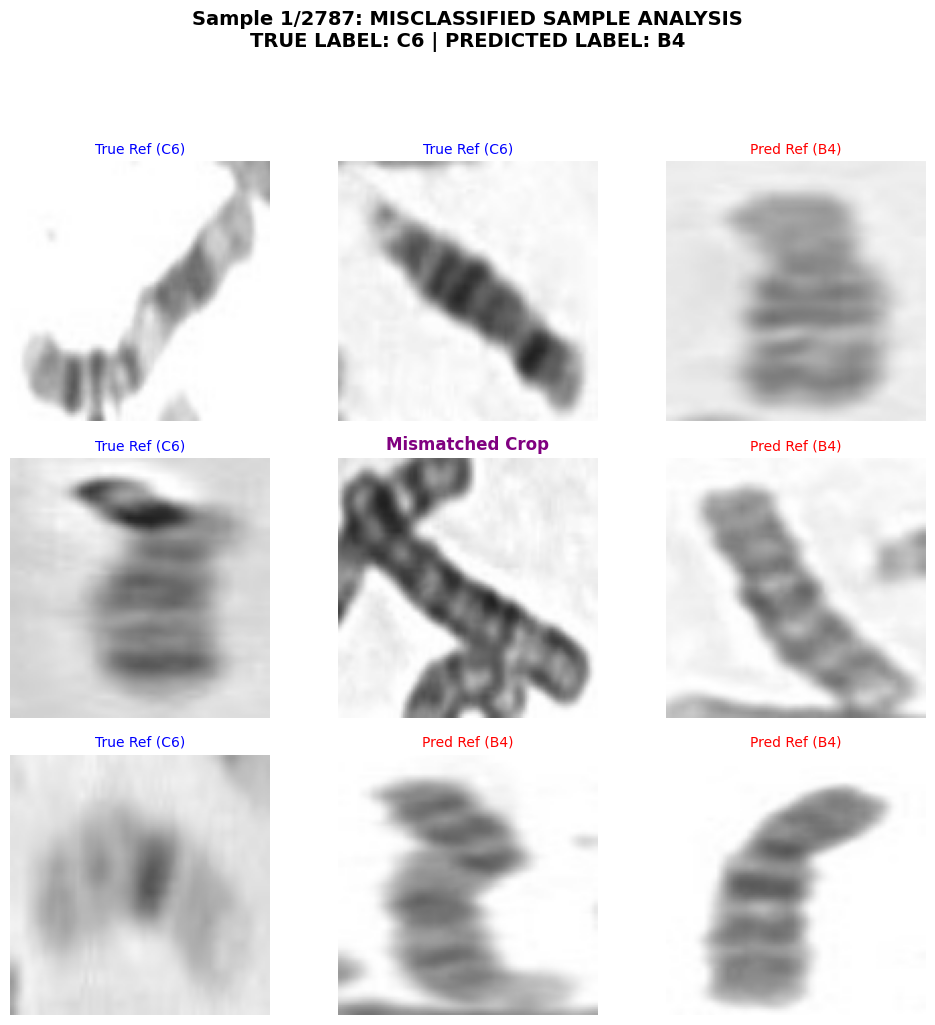


Decision for this sample:
 [1] Keep (The label is correct, model needs to learn this hard sample)
 [2] Discard (The label is incorrect, this is a dataset error)
 [3] Confused/Unsure (Set aside for later review)
 [S] Skip (Come back later)


Review interrupted by user.


--- Review Session Finished ---
Total samples kept for retraining: 0
Total samples discarded (potential label errors): 0
Total samples marked 'Confused' for later review: 0
Total samples skipped: 2787

Ready for Phase 3: Dataset Export.


In [10]:
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import random
from tqdm.notebook import tqdm
from IPython.display import display, clear_output

# --- 0. ROBUST LIST INITIALIZATION (FIXING NameError) ---
# Ensure these lists exist in the global scope if not already loaded by Phase 1 or checkpoint.
if 'keep_list' not in globals():
    keep_list = []
if 'discard_list' not in globals():
    discard_list = []
if 'confused_list' not in globals(): # <-- CRITICAL FIX
    confused_list = []

# --- Globals needed from previous cells ---
# BASE_PATH, IMAGE_SIZE, class_to_index, CLASS_NAMES
# correctly_matched_ids, misclassified_data
# images_path, annotations_path
# MIN_CROP_DIMENSION = 10

# Note: We assume the variables from the previous notebook cells are available 
# in the current execution environment.

N_REFERENCES = 4 # Number of correctly matched samples to display for reference (4 per class)

# Helper function to extract and process a single crop image
def extract_crop_image(crop_id):
    """
    Reads the original image, extracts the bounding box crop defined by the crop_id,
    resizes it, and returns the normalized image array (0-255).
    """
    try:
        # crop_id format: "image_name_crop_index"
        parts = crop_id.split('_crop_')
        image_name = parts[0]
        crop_index = int(parts[1])
        
        image_path = os.path.join(images_path, image_name + ".jpg")
        xml_path = os.path.join(annotations_path, image_name + ".xml")

        image = cv2.imread(image_path)
        if image is None:
            return None

        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # Find the specific object based on index
        member = root.findall('object')[crop_index]
        
        bndbox = member.find('bndbox')
        xmin, ymin = int(bndbox.find('xmin').text), int(bndbox.find('ymin').text)
        xmax, ymax = int(bndbox.find('xmax').text), int(bndbox.find('ymax').text)

        crop = image[ymin:ymax, xmin:xmax]
        if crop.size == 0:
            return None
        
        h, w, _ = crop.shape
        if h < MIN_CROP_DIMENSION or w < MIN_CROP_DIMENSION: 
            return None

        # Resize and return (do not normalize, we want 0-255 for visualization)
        resized_crop = cv2.resize(crop, IMAGE_SIZE)
        return cv2.cvtColor(resized_crop, cv2.COLOR_BGR2RGB)

    except Exception as e:
        # print(f"Error processing {crop_id}: {e}")
        return None

def inspect_sample(index, misclassified_sample):
    """
    Displays the misclassified sample along with reference samples and prompts for user decision.
    Appends the decision to keep_list, discard_list, or confused_list.
    """
    crop_id, y_true, y_pred = misclassified_sample
    true_name = CLASS_NAMES[y_true]
    pred_name = CLASS_NAMES[y_pred]

    misclassified_img = extract_crop_image(crop_id)
    if misclassified_img is None:
        print(f"Skipping corrupt or too small sample: {crop_id}")
        return

    # --- 1. Get Reference Samples ---
    
    # Randomly select N_REFERENCES of correctly classified images for the True Class
    true_ref_ids = correctly_matched_ids.get(y_true, [])
    # Handle cases where we don't have enough references
    selected_true_ref_ids = random.sample(true_ref_ids, min(N_REFERENCES, len(true_ref_ids)))
    
    # Randomly select N_REFERENCES of correctly classified images for the Predicted Class
    pred_ref_ids = correctly_matched_ids.get(y_pred, [])
    selected_pred_ref_ids = random.sample(pred_ref_ids, min(N_REFERENCES, len(pred_ref_ids)))

    # --- 2. Plotting ---
    
    # Create the figure: 3x3 grid (Misclassified is center, surrounded by references)
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    fig.suptitle(
        f"Sample {index+1}/{len(misclassified_data)}: MISCLASSIFIED SAMPLE ANALYSIS\n"
        f"TRUE LABEL: {true_name} | PREDICTED LABEL: {pred_name}", 
        fontsize=14, fontweight='bold', y=1.02
    )

    # Flatten axes for easier indexing
    axes = axes.flatten()

    # --- True Class References (Top Row and Left Column) ---
    axes[0].set_title(f"True Ref ({true_name})", fontsize=10, color='blue')
    axes[1].set_title(f"True Ref ({true_name})", fontsize=10, color='blue')
    axes[3].set_title(f"True Ref ({true_name})", fontsize=10, color='blue')
    axes[6].set_title(f"True Ref ({true_name})", fontsize=10, color='blue')

    ref_indices = [0, 1, 3, 6]
    for i, ref_id in enumerate(selected_true_ref_ids[:4]):
        img = extract_crop_image(ref_id)
        if img is not None:
            axes[ref_indices[i]].imshow(img)
        axes[ref_indices[i]].axis('off')

    # --- Predicted Class References (Right Column and Bottom Row) ---
    axes[2].set_title(f"Pred Ref ({pred_name})", fontsize=10, color='red')
    axes[5].set_title(f"Pred Ref ({pred_name})", fontsize=10, color='red')
    axes[7].set_title(f"Pred Ref ({pred_name})", fontsize=10, color='red')
    axes[8].set_title(f"Pred Ref ({pred_name})", fontsize=10, color='red')

    ref_indices = [2, 5, 7, 8]
    for i, ref_id in enumerate(selected_pred_ref_ids[:4]):
        img = extract_crop_image(ref_id)
        if img is not None:
            axes[ref_indices[i]].imshow(img)
        axes[ref_indices[i]].axis('off')
        
    # --- Misclassified Sample (Center) ---
    axes[4].imshow(misclassified_img)
    axes[4].set_title(f"Mismatched Crop", fontsize=12, color='purple', fontweight='bold')
    axes[4].set_xlabel(f"ID: {crop_id}", fontsize=8)
    axes[4].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout for suptitle
    plt.show()

    # --- 3. User Decision Loop ---
    
    while True:
        # Prompt user input
        print("\nDecision for this sample:")
        print(" [1] Keep (The label is correct, model needs to learn this hard sample)")
        print(" [2] Discard (The label is incorrect, this is a dataset error)")
        print(" [3] Confused/Unsure (Set aside for later review)") 
        print(" [S] Skip (Come back later)")
        user_input = input("Enter 1, 2, 3, or S: ").strip().upper() 

        if user_input == '1':
            keep_list.append(misclassified_sample)
            print(f"-> KEPT sample {crop_id}. Added to keep_list ({len(keep_list)} samples kept).")
            break
        elif user_input == '2':
            discard_list.append(misclassified_sample)
            print(f"-> DISCARDED sample {crop_id}. Added to discard_list ({len(discard_list)} samples discarded).")
            break
        elif user_input == '3': 
            confused_list.append(misclassified_sample)
            print(f"-> CONFUSED sample {crop_id}. Added to confused_list ({len(confused_list)} samples confused).")
            break
        elif user_input == 'S':
            print(f"-> SKIPPING sample {crop_id}.")
            break
        else:
            print("Invalid input. Please enter 1, 2, 3, or S.")

# --- 4. Main Inspection Loop Execution ---

print("--- Starting Interactive Inspection ---")
print(f"Total misclassified samples to review: {len(misclassified_data)}")

# The following loop handles the inspection process
try:
    # Calculate initial number of already processed samples (in case of restart)
    # This calculation is now safe because the lists are initialized at the top.
    processed_count = len(keep_list) + len(discard_list) + len(confused_list)
    
    # Iterate over only the unprocessed samples
    unprocessed_data = misclassified_data[processed_count:]

    for i, sample_data in tqdm(enumerate(unprocessed_data), total=len(unprocessed_data), initial=processed_count, desc="Reviewing Samples"):
        # Use clear_output to ensure a clean display for each iteration in the notebook
        clear_output(wait=True) 
        # The index passed to inspect_sample should be the global index
        inspect_sample(i + processed_count, sample_data) 
        
except KeyboardInterrupt:
    print("\n\nReview interrupted by user.")
    
# Final summary after the loop or interruption
total_processed = len(keep_list) + len(discard_list) + len(confused_list)
total_skipped = len(misclassified_data) - total_processed
    
print("\n\n--- Review Session Finished ---")
print(f"Total samples kept for retraining: {len(keep_list)}")
print(f"Total samples discarded (potential label errors): {len(discard_list)}")
print(f"Total samples marked 'Confused' for later review: {len(confused_list)}")
print(f"Total samples skipped: {total_skipped}")

print("\nReady for Phase 3: Dataset Export.")

In [20]:
import os
import numpy as np
from collections import defaultdict
from itertools import chain

# --- 1. Define Output Paths ---
# Assuming you want to save the output in the working directory
OUTPUT_DIR = '.' 
KEPT_MISTMATCHED_FILE = os.path.join(OUTPUT_DIR, 'kept_mismatched_crops.txt')
RETRAIN_SET_FILE = os.path.join(OUTPUT_DIR, 'retrain_set.txt')

print("--- Starting Phase 3: Dataset Export ---")

# --- 2. Extract Kept Mismatched Crop IDs ---
# The keep_list contains tuples: (crop_id, true_index, pred_index)
kept_crop_ids = [item[0] for item in keep_list]

print(f"Total hard samples kept for retraining: {len(kept_crop_ids)}")
print(f"Total samples discarded (potential label errors): {len(discard_list)}")

# --- 3. Generate Kept Mismatched File (Dataset 1) ---
try:
    with open(KEPT_MISTMATCHED_FILE, 'w') as f:
        for crop_id in kept_crop_ids:
            f.write(f"{crop_id}\n")
    print(f"Successfully exported {len(kept_crop_ids)} kept misclassified crops to: {KEPT_MISTMATCHED_FILE}")
except Exception as e:
    print(f"Error writing kept mismatched crops file: {e}")

# --- 4. Prepare the New Consolidated Training Set (Dataset 2) ---

# Get all crop IDs from the correctly matched index
all_matched_ids = list(chain.from_iterable(correctly_matched_ids.values()))

print(f"Total correctly classified samples (base set): {len(all_matched_ids)}")

# Combine the matched IDs with the kept mismatched IDs
# This creates the final, improved training set
new_training_set = all_matched_ids + kept_crop_ids

# Shuffle the combined list to ensure good batching during future training
np.random.shuffle(new_training_set)

print(f"New Training Set Size (Matched + Kept): {len(new_training_set)}")

# --- 5. Generate New Training Set File (Dataset 2) ---
try:
    with open(RETRAIN_SET_FILE, 'w') as f:
        for crop_id in new_training_set:
            f.write(f"{crop_id}\n")
    print(f"Successfully exported new training set to: {RETRAIN_SET_FILE}")
except Exception as e:
    print(f"Error writing new training set file: {e}")

print("\n--- Phase 3 Complete ---")
print("You now have two files ready for the next steps:")
print(f"1. {KEPT_MISTMATCHED_FILE}: List of hard samples to monitor.")
print(f"2. {RETRAIN_SET_FILE}: The complete, refined dataset ready for model retraining.")

--- Starting Phase 3: Dataset Export ---
Total hard samples kept for retraining: 0
Total samples discarded (potential label errors): 0
Successfully exported 0 kept misclassified crops to: ./kept_mismatched_crops.txt
Total correctly classified samples (base set): 169268
New Training Set Size (Matched + Kept): 169268
Successfully exported new training set to: ./retrain_set.txt

--- Phase 3 Complete ---
You now have two files ready for the next steps:
1. ./kept_mismatched_crops.txt: List of hard samples to monitor.
2. ./retrain_set.txt: The complete, refined dataset ready for model retraining.



Analyzing dimensions for 2787 misclassified samples...


Extracting Dimensions:   0%|          | 0/2787 [00:00<?, ?it/s]

Successfully collected data for 2787 valid crops.


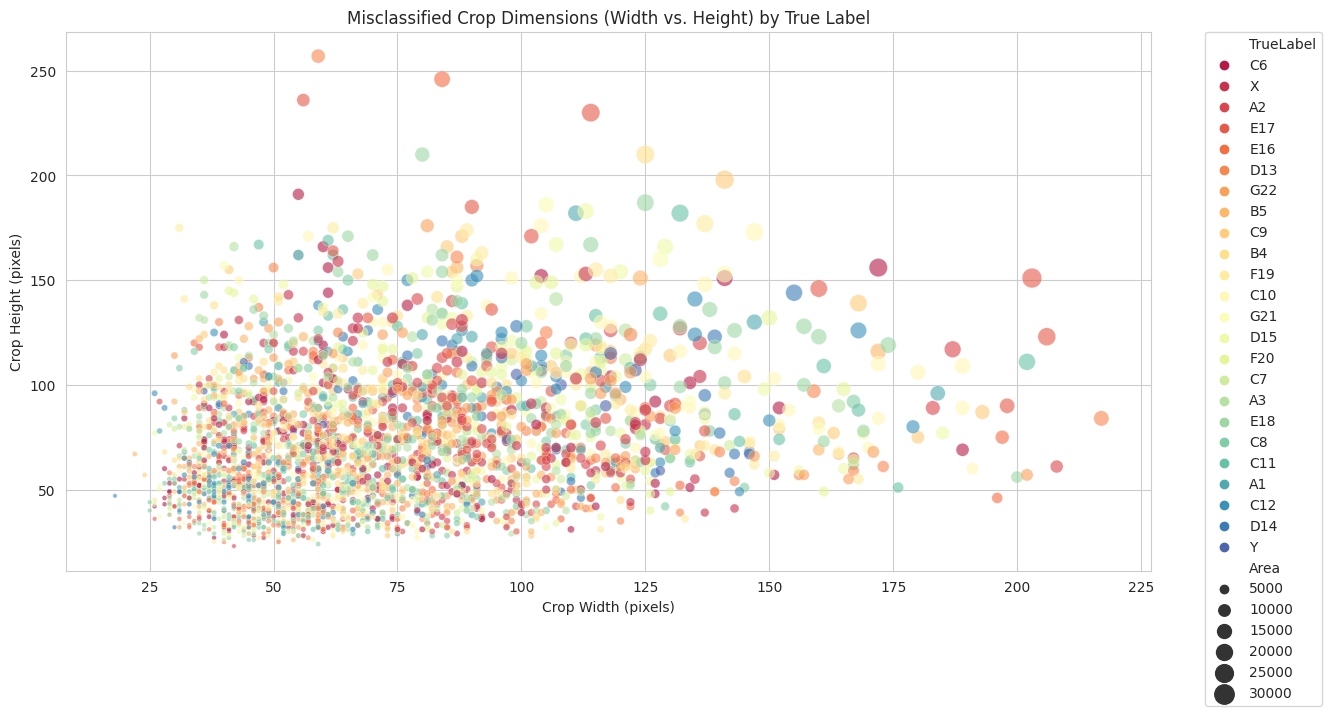

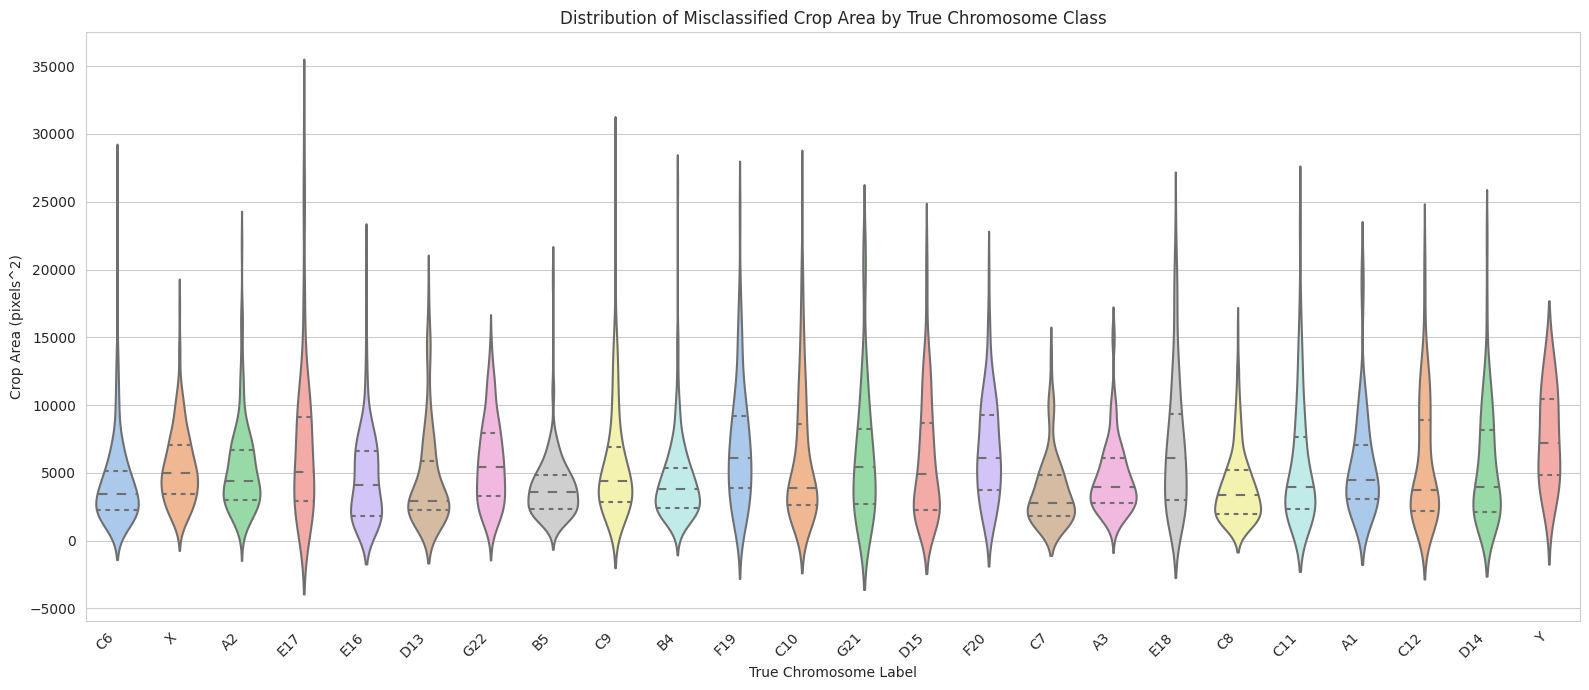

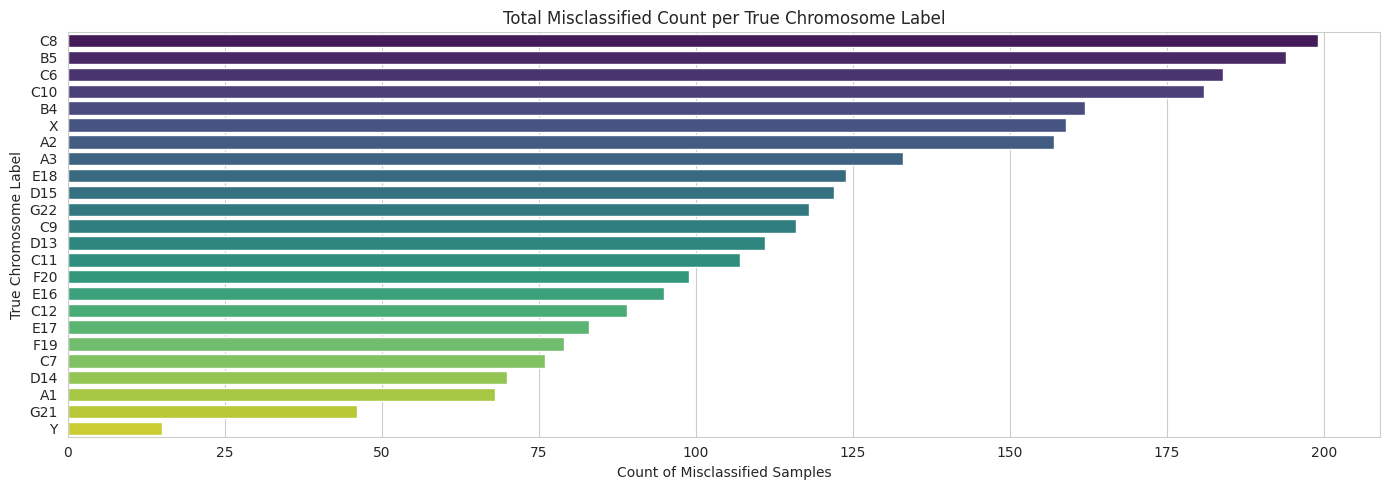

In [11]:
import os
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# --- Globals assumed to be available from previous cells ---
# misclassified_data: List of (crop_id, y_true, y_pred) tuples
# CLASS_NAMES: List of chromosome class names (e.g., ['CHR1', 'CHR2', ...])
# annotations_path: Path to the XML annotations directory
# MIN_CROP_DIMENSION: (e.g., 10) used to filter corrupted crops

# --- 1. Data Extraction Function ---

def get_crop_dimensions(crop_id, annotations_path, min_dim=10):
    """
    Extracts the bounding box dimensions (width and height) for a given crop_id.
    Returns a dictionary or None if the file/crop is invalid.
    """
    try:
        # crop_id format: "image_name_crop_index"
        parts = crop_id.split('_crop_')
        image_name = parts[0]
        crop_index = int(parts[1])
        
        xml_path = os.path.join(annotations_path, image_name + ".xml")

        if not os.path.exists(xml_path):
            return None

        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # Find the specific object based on index
        member = root.findall('object')[crop_index]
        
        bndbox = member.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        width = xmax - xmin
        height = ymax - ymin
        area = width * height

        # Filter out crops that are too small (should match generator logic)
        if width < min_dim or height < min_dim or area <= 0:
            return None

        return {
            'width': width,
            'height': height,
            'area': area
        }

    except Exception:
        return None

# --- 2. Main Analysis Loop ---

def analyze_misclassified_sizes(misclassified_data, CLASS_NAMES, annotations_path):
    """
    Iterates through misclassified data, extracts dimensions, and creates a DataFrame.
    """
    analysis_data = []
    
    print(f"\nAnalyzing dimensions for {len(misclassified_data)} misclassified samples...")
    
    for crop_id, y_true, y_pred in tqdm(misclassified_data, desc="Extracting Dimensions"):
        dimensions = get_crop_dimensions(crop_id, annotations_path, MIN_CROP_DIMENSION)
        
        if dimensions:
            analysis_data.append({
                'CropID': crop_id,
                'TrueIndex': y_true,
                'PredIndex': y_pred,
                'TrueLabel': CLASS_NAMES[y_true],
                'PredLabel': CLASS_NAMES[y_pred],
                'Width': dimensions['width'],
                'Height': dimensions['height'],
                'Area': dimensions['area']
            })

    # Create the pandas DataFrame for easy analysis and plotting
    df = pd.DataFrame(analysis_data)
    print(f"Successfully collected data for {len(df)} valid crops.")
    return df

# --- 3. Visualization Functions ---

def generate_size_plots(df):
    """Generates and displays various plots based on the misclassified size data."""
    if df.empty:
        print("No valid misclassified data to plot.")
        return

    # Set up plotting style
    sns.set_style("whitegrid")
    
    # 3a. Scatter Plot: Dimension Distribution
    plt.figure(figsize=(14, 7))
    sns.scatterplot(
        data=df, 
        x='Width', 
        y='Height', 
        hue='TrueLabel', 
        size='Area', 
        sizes=(10, 200),
        alpha=0.6,
        palette='Spectral',
    )
    plt.title('Misclassified Crop Dimensions (Width vs. Height) by True Label')
    plt.xlabel('Crop Width (pixels)')
    plt.ylabel('Crop Height (pixels)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.show()
    

    # 3b. Violin Plot: Distribution of Crop Area by True Class
    # This helps see if the model struggles with a specific size range for a class.
    plt.figure(figsize=(16, 7))
    sns.violinplot(
        data=df, 
        x='TrueLabel', 
        y='Area', 
        inner="quartile", 
        palette="pastel"
    )
    plt.title('Distribution of Misclassified Crop Area by True Chromosome Class')
    plt.xlabel('True Chromosome Label')
    plt.ylabel('Crop Area (pixels^2)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    

    # 3c. Count Plot: Mismatched Prediction Count
    # This shows which classes are most frequently misclassified (either as True or Predicted)
    plt.figure(figsize=(14, 5))
    ax = sns.countplot(
        data=df, 
        y='TrueLabel', 
        order=df['TrueLabel'].value_counts().index, 
        palette='viridis'
    )
    plt.title('Total Misclassified Count per True Chromosome Label')
    plt.xlabel('Count of Misclassified Samples')
    plt.ylabel('True Chromosome Label')
    plt.tight_layout()
    plt.show()

# --- 4. Execution ---

# You must ensure 'misclassified_data', 'CLASS_NAMES', 'annotations_path', and 
# 'MIN_CROP_DIMENSION' are defined and accessible in the global scope 
# before running this cell.

# 1. Run the analysis
analysis_df = analyze_misclassified_sizes(misclassified_data, CLASS_NAMES, annotations_path)

# 2. Generate the plots
if not analysis_df.empty:
    generate_size_plots(analysis_df)
else:
    print("Could not generate plots because the DataFrame is empty.")

--- 1. Generating Misclassification Size Facts (Equal Intervals) ---

Total Misclassified Samples Analyzed:  2787

Size Categories Defined by Equal Interval (4 Bins):
  Bin 1: Small: 846 to 8,297 pixels^2
  Bin 2: Medium-Small: 8,297 to 15,749 pixels^2
  Bin 3: Medium-Large: 15,749 to 23,201 pixels^2
  Bin 4: Large: 23,201 to 30,653 pixels^2

--- Misclassified Sample Distribution by Size ---
                     Count  Percentage
SizeCategory                          
Bin 1: Small          2297       82.42
Bin 2: Medium-Small    423       15.18
Bin 3: Medium-Large     55        1.97
Bin 4: Large            12        0.43


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


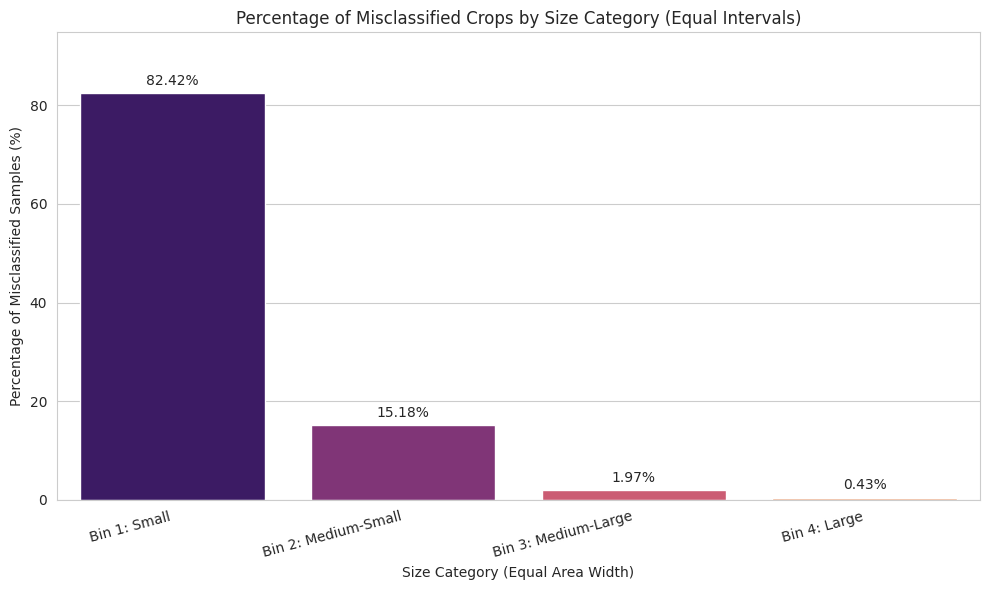

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Globals assumed to be available from previous cells ---
# analysis_df: DataFrame containing misclassified sample dimensions (from misclassification_analysis.py)

def generate_size_facts(df):
    """
    Analyzes the 'Area' column of the misclassified crops, defines size bins,
    and calculates the percentage distribution across these bins using EQUAL INTERVALS.
    """
    if df.empty:
        print("Analysis DataFrame is empty. Please run the size extraction step first.")
        return

    print("--- 1. Generating Misclassification Size Facts (Equal Intervals) ---")
    
    # --- Define Equal Interval Size Bins ---
    min_area = df['Area'].min()
    max_area = df['Area'].max()
    num_bins = 4
    
    # Create 4 bins of equal width. np.linspace gives 5 evenly spaced points (4 intervals)
    bins = np.linspace(min_area, max_area, num_bins + 1).tolist()
    
    # Adjust boundaries slightly for pd.cut to include min and max correctly
    bins[0] = bins[0] - 1 
    bins[-1] = bins[-1] + 1
    
    # Define labels for the equal intervals
    labels = ['Bin 1: Small', 'Bin 2: Medium-Small', 'Bin 3: Medium-Large', 'Bin 4: Large']
    
    # Categorize the misclassified samples based on area
    df['SizeCategory'] = pd.cut(df['Area'], bins=bins, labels=labels, right=True, include_lowest=True)
    
    # --- Calculate Distribution ---
    
    total_misclassified = len(df)
    # Sort index is crucial here as pd.cut creates categories in the correct order
    size_distribution = df['SizeCategory'].value_counts().sort_index() 
    size_percentage = (size_distribution / total_misclassified) * 100
    
    facts_df = pd.DataFrame({
        'Count': size_distribution,
        'Percentage': size_percentage.round(2)
    })
    
    # --- Print Facts and Ranges ---
    
    print("\nTotal Misclassified Samples Analyzed: ", total_misclassified)
    print("\nSize Categories Defined by Equal Interval (4 Bins):")
    
    # Calculate and display the pixel range for each category
    # Use the original (unmodified) linear space points for clean display of ranges
    clean_bins = np.linspace(min_area, max_area, num_bins + 1).tolist()
    
    for i in range(num_bins):
        lower_bound = f"{int(clean_bins[i]):,}"
        upper_bound = f"{int(clean_bins[i+1]):,}"
            
        print(f"  {labels[i]}: {lower_bound} to {upper_bound} pixels^2")
        
    print("\n--- Misclassified Sample Distribution by Size ---")
    print(facts_df)
    
    # --- Visualization: Bar Plot of Percentage ---
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        x=facts_df.index,
        y='Percentage',
        data=facts_df.reset_index(),
        palette='magma'
    )
    
    # Add labels on the bars
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')
        
    plt.title('Percentage of Misclassified Crops by Size Category (Equal Intervals)')
    plt.xlabel('Size Category (Equal Area Width)')
    plt.ylabel('Percentage of Misclassified Samples (%)')
    plt.ylim(0, facts_df['Percentage'].max() * 1.15)
    plt.xticks(rotation=15, ha='right') # Add rotation for longer labels
    plt.tight_layout()
    plt.show()


# --- Execution ---

# Ensure the DataFrame is available before calling the function
generate_size_facts(analysis_df)


--- 1. Generating Misclassification Size Facts (Equal Intervals) ---

Total Misclassified Samples Analyzed:  2787

Size Categories Defined by Equal Interval (20 Bins):
  Bin 1: 846 to 2,336 pixels^2
  Bin 2: 2,336 to 3,826 pixels^2
  Bin 3: 3,826 to 5,317 pixels^2
  Bin 4: 5,317 to 6,807 pixels^2
  Bin 5: 6,807 to 8,297 pixels^2
  ... 15 additional bins not shown ...
  Bin 20: 29,162 to 30,653 pixels^2

--- Misclassified Sample Distribution by Size ---
              Count  Percentage
SizeCategory                   
Bin 1           588       21.10
Bin 2           676       24.26
Bin 3           481       17.26
Bin 4           322       11.55
Bin 5           230        8.25
Bin 6           156        5.60
Bin 7           112        4.02
Bin 8            73        2.62
Bin 9            51        1.83
Bin 10           31        1.11
Bin 11           17        0.61
Bin 12           13        0.47
Bin 13           12        0.43
Bin 14           10        0.36
Bin 15            3        0.11

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


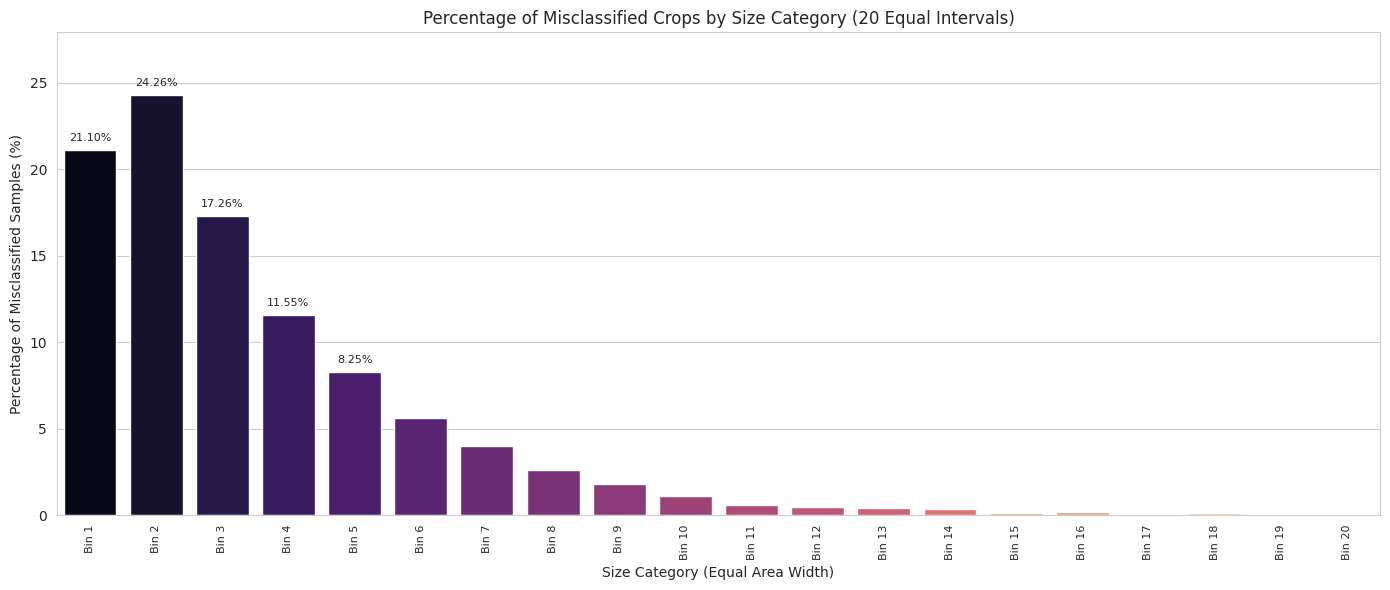

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Globals assumed to be available from previous cells ---
# analysis_df: DataFrame containing misclassified sample dimensions (from misclassification_analysis.py)

def generate_size_facts(df):
    """
    Analyzes the 'Area' column of the misclassified crops, defines size bins,
    and calculates the percentage distribution across these bins using EQUAL INTERVALS.
    """
    if df.empty:
        print("Analysis DataFrame is empty. Please run the size extraction step first.")
        return

    print("--- 1. Generating Misclassification Size Facts (Equal Intervals) ---")
    
    # --- Define Equal Interval Size Bins ---
    min_area = df['Area'].min()
    max_area = df['Area'].max()
    num_bins = 20 # CHANGED FROM 4 TO 20
    
    # Create 20 bins of equal width. np.linspace gives 21 evenly spaced points (20 intervals)
    bins = np.linspace(min_area, max_area, num_bins + 1).tolist()
    
    # Adjust boundaries slightly for pd.cut to include min and max correctly
    bins[0] = bins[0] - 1 
    bins[-1] = bins[-1] + 1
    
    # Define labels for the equal intervals (using a descriptive list for 20 bins)
    labels = [f'Bin {i+1}' for i in range(num_bins)]
    
    # Categorize the misclassified samples based on area
    df['SizeCategory'] = pd.cut(df['Area'], bins=bins, labels=labels, right=True, include_lowest=True)
    
    # --- Calculate Distribution ---
    
    total_misclassified = len(df)
    # Sort index is crucial here as pd.cut creates categories in the correct order
    size_distribution = df['SizeCategory'].value_counts().sort_index() 
    size_percentage = (size_distribution / total_misclassified) * 100
    
    facts_df = pd.DataFrame({
        'Count': size_distribution,
        'Percentage': size_percentage.round(2)
    })
    
    # --- Print Facts and Ranges ---
    
    print("\nTotal Misclassified Samples Analyzed: ", total_misclassified)
    print("\nSize Categories Defined by Equal Interval (20 Bins):")
    
    # Calculate and display the pixel range for each category
    # Use the original (unmodified) linear space points for clean display of ranges
    clean_bins = np.linspace(min_area, max_area, num_bins + 1).tolist()
    
    # Print only the first and last few bins for brevity in the console output
    for i in range(min(num_bins, 5)):
        lower_bound = f"{int(clean_bins[i]):,}"
        upper_bound = f"{int(clean_bins[i+1]):,}"
            
        print(f"  {labels[i]}: {lower_bound} to {upper_bound} pixels^2")

    if num_bins > 5:
        print(f"  ... {num_bins - 5} additional bins not shown ...")

        # Print the last bin
        lower_bound = f"{int(clean_bins[num_bins - 1]):,}"
        upper_bound = f"{int(clean_bins[num_bins]):,}"
        print(f"  {labels[num_bins - 1]}: {lower_bound} to {upper_bound} pixels^2")
        
    print("\n--- Misclassified Sample Distribution by Size ---")
    print(facts_df)
    
    # --- Visualization: Bar Plot of Percentage ---
    plt.figure(figsize=(14, 6)) # Increased figure size for 20 bars
    ax = sns.barplot(
        x=facts_df.index,
        y='Percentage',
        data=facts_df.reset_index(),
        palette='magma'
    )
    
    # Add labels on the bars (only for the first 5 bars to avoid clutter)
    for i, p in enumerate(ax.patches):
        if i < 5:
            ax.annotate(f"{p.get_height():.2f}%", 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', 
                        xytext=(0, 9), 
                        textcoords='offset points',
                        fontsize=8)
        
    plt.title('Percentage of Misclassified Crops by Size Category (20 Equal Intervals)')
    plt.xlabel('Size Category (Equal Area Width)')
    plt.ylabel('Percentage of Misclassified Samples (%)')
    plt.ylim(0, facts_df['Percentage'].max() * 1.15)
    plt.xticks(rotation=90, ha='center', fontsize=8) # Rotate labels for readability
    plt.tight_layout()
    plt.show()
    


# --- Execution ---

# Ensure the DataFrame is available before calling the function
generate_size_facts(analysis_df)


Extracting dimensions for 169268 correctly matched samples...


Extracting Matched Dimensions:   0%|          | 0/169268 [00:00<?, ?it/s]

Successfully collected data for 169268 valid matched crops.

--- Comparative Size Analysis (20 Equal Intervals) ---
Total Matched Samples Analyzed: 169,268
Total Mismatched Samples Analyzed: 2,787
Overall Area Range: 544 to 43,884 pixels^2

Size Categories Defined by Equal Interval (20 Bins):
  Bin 1: 544 to 2,711 pixels^2
  Bin 2: 2,711 to 4,878 pixels^2
  Bin 3: 4,878 to 7,045 pixels^2
  Bin 4: 7,045 to 9,212 pixels^2
  Bin 5: 9,212 to 11,379 pixels^2
  ... 15 additional bins not shown ...
  Bin 20: 41,717 to 43,884 pixels^2

--- Comparative Distribution Table (%) ---
              MatchedPercentage  MismatchedPercentage
SizeCategory                                         
Bin 1                     25.58                 28.70
Bin 2                     30.20                 29.60
Bin 3                     20.00                 17.19
Bin 4                     11.12                 10.62
Bin 5                      6.09                  6.32
Bin 6                      3.27              

/tmp/ipykernel_47/2934159330.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distribution = combined_df.groupby('SizeCategory')['is_mismatched'].agg(['count', 'sum'])
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence th

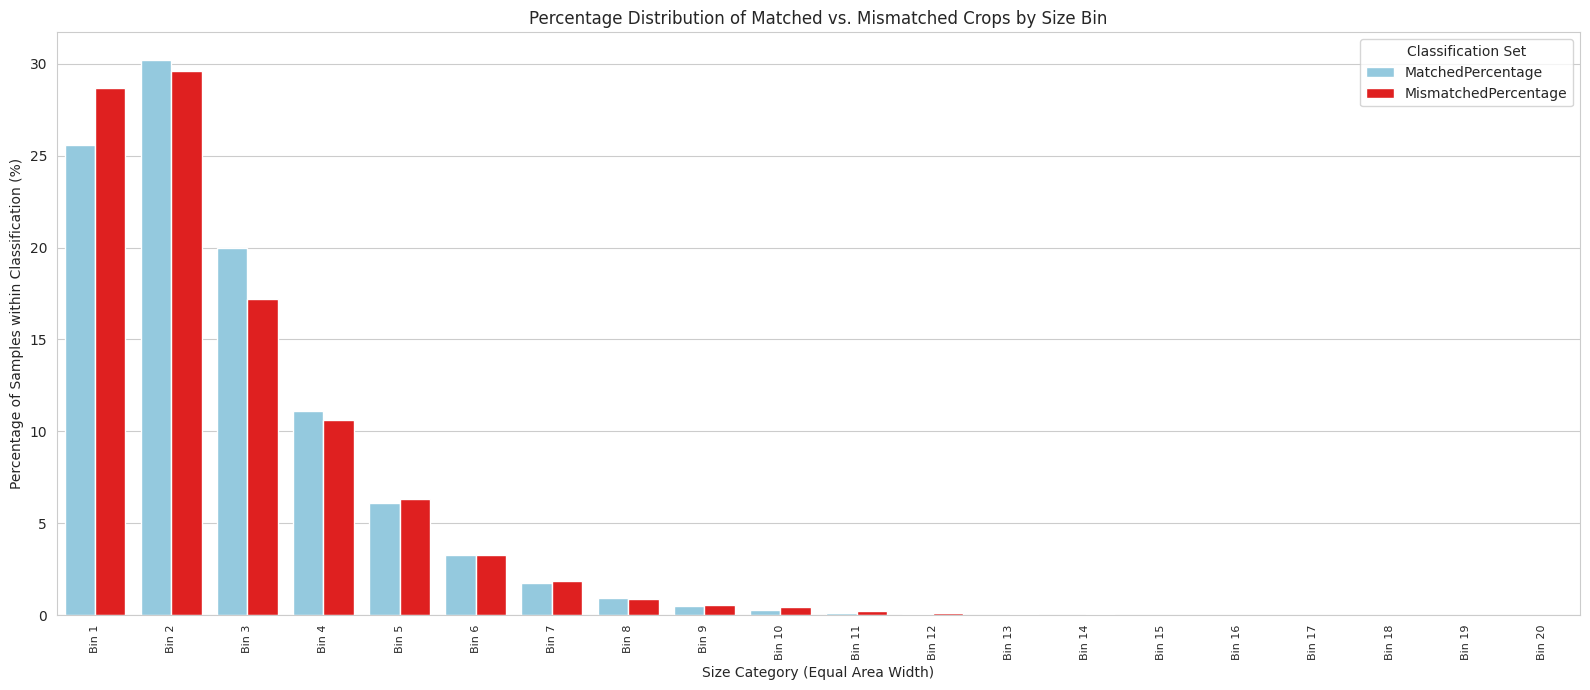

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import xml.etree.ElementTree as ET
from tqdm.notebook import tqdm
from itertools import chain

# --- Globals assumed to be available from previous cells ---
# analysis_df: DataFrame containing MISCLASSIFIED sample dimensions 
# correctly_matched_ids: Dictionary mapping class index to list of correctly matched crop IDs
# annotations_path: Path to the XML annotations directory
# MIN_CROP_DIMENSION: (e.g., 10) used to filter corrupted crops

# --- Helper Function to Extract Dimensions (Copied from analysis file for self-containment) ---

def get_crop_dimensions(crop_id, annotations_path, min_dim):
    """
    Extracts the bounding box dimensions (width and height) for a given crop_id.
    Returns a dictionary or None if the file/crop is invalid.
    """
    try:
        # crop_id format: "image_name_crop_index"
        parts = crop_id.split('_crop_')
        image_name = parts[0]
        crop_index = int(parts[1])
        
        xml_path = os.path.join(annotations_path, image_name + ".xml")

        if not os.path.exists(xml_path):
            return None

        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # Find the specific object based on index
        member = root.findall('object')[crop_index]
        
        bndbox = member.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        width = xmax - xmin
        height = ymax - ymin
        area = width * height

        if width < min_dim or height < min_dim or area <= 0:
            return None

        return {
            'Area': area,
            'is_mismatched': 0 # Mark as Matched
        }

    except Exception:
        return None

# --- New Function to Process Matched Data ---

def create_matched_df(matched_ids_dict, annotations_path, min_dim):
    """Processes all correctly matched crop IDs into a DataFrame."""
    
    all_matched_ids = list(chain.from_iterable(matched_ids_dict.values()))
    matched_data = []
    
    print(f"\nExtracting dimensions for {len(all_matched_ids)} correctly matched samples...")
    
    for crop_id in tqdm(all_matched_ids, desc="Extracting Matched Dimensions"):
        dimensions = get_crop_dimensions(crop_id, annotations_path, min_dim)
        
        if dimensions:
            matched_data.append(dimensions)
            
    df = pd.DataFrame(matched_data)
    print(f"Successfully collected data for {len(df)} valid matched crops.")
    return df

# --- Main Comparison Function (REPLACING generate_size_facts) ---

def compare_size_distributions(mismatched_df, matched_ids_dict, annotations_path, min_dim):
    """
    Analyzes and compares the size distributions of matched and mismatched crops 
    using 20 equal-interval bins.
    """
    
    if mismatched_df.empty:
        print("Mismatched analysis DataFrame is empty. Cannot proceed.")
        return

    # 1. Create the Matched DataFrame
    matched_df = create_matched_df(matched_ids_dict, annotations_path, min_dim)
    
    if matched_df.empty:
        print("Matched analysis DataFrame is empty. Cannot proceed.")
        return

    # 2. Combine the datasets and define bins based on the full range
    # Ensure mismatched_df has the 'is_mismatched' column (1)
    mismatched_df['is_mismatched'] = 1 
    
    # Select only the necessary 'Area' and 'is_mismatched' columns from both DFs
    matched_area = matched_df[['Area', 'is_mismatched']]
    mismatched_area = mismatched_df[['Area', 'is_mismatched']]
    
    combined_df = pd.concat([matched_area, mismatched_area], ignore_index=True)
    
    min_area = combined_df['Area'].min()
    max_area = combined_df['Area'].max()
    num_bins = 20 
    
    # Create 20 bins of equal width across the ENTIRE dataset's size range
    bins = np.linspace(min_area, max_area, num_bins + 1).tolist()
    
    # Adjust boundaries slightly for pd.cut
    bins[0] = bins[0] - 1 
    bins[-1] = bins[-1] + 1
    
    # Define labels
    labels = [f'Bin {i+1}' for i in range(num_bins)]
    
    # Apply bins to the combined dataset
    combined_df['SizeCategory'] = pd.cut(combined_df['Area'], bins=bins, labels=labels, right=True, include_lowest=True)
    
    # --- 3. Calculate Distribution and Percentages ---
    
    # Group the combined data by category and classification type (matched/mismatched)
    distribution = combined_df.groupby('SizeCategory')['is_mismatched'].agg(['count', 'sum'])
    distribution = distribution.rename(columns={'count': 'TotalInBin', 'sum': 'MismatchedCount'})
    
    # Calculate counts and percentages for Matched and Mismatched
    distribution['MatchedCount'] = distribution['TotalInBin'] - distribution['MismatchedCount']
    
    total_mismatched = distribution['MismatchedCount'].sum()
    total_matched = distribution['MatchedCount'].sum()
    
    distribution['MismatchedPercentage'] = (distribution['MismatchedCount'] / total_mismatched * 100).round(2)
    distribution['MatchedPercentage'] = (distribution['MatchedCount'] / total_matched * 100).round(2)
    
    # --- 4. Print Facts and Ranges ---
    
    print("\n--- Comparative Size Analysis (20 Equal Intervals) ---")
    print(f"Total Matched Samples Analyzed: {total_matched:,}")
    print(f"Total Mismatched Samples Analyzed: {total_mismatched:,}")
    print(f"Overall Area Range: {min_area:,.0f} to {max_area:,.0f} pixels^2")
    
    print("\nSize Categories Defined by Equal Interval (20 Bins):")
    
    clean_bins = np.linspace(min_area, max_area, num_bins + 1).tolist()
    for i in range(min(num_bins, 5)):
        lower_bound = f"{int(clean_bins[i]):,}"
        upper_bound = f"{int(clean_bins[i+1]):,}"
        print(f"  {labels[i]}: {lower_bound} to {upper_bound} pixels^2")

    if num_bins > 5:
        print(f"  ... {num_bins - 5} additional bins not shown ...")

        lower_bound = f"{int(clean_bins[num_bins - 1]):,}"
        upper_bound = f"{int(clean_bins[num_bins]):,}"
        print(f"  {labels[num_bins - 1]}: {lower_bound} to {upper_bound} pixels^2")

    print("\n--- Comparative Distribution Table (%) ---")
    print(distribution[['MatchedPercentage', 'MismatchedPercentage']])
    
    # --- 5. Visualization: Comparative Bar Plot ---
    
    plot_df = distribution[['MatchedPercentage', 'MismatchedPercentage']].stack().reset_index()
    plot_df.columns = ['SizeCategory', 'Classification', 'Percentage']
    
    plt.figure(figsize=(16, 7)) 
    sns.barplot(
        x='SizeCategory',
        y='Percentage',
        hue='Classification',
        data=plot_df,
        palette={'MatchedPercentage': 'skyblue', 'MismatchedPercentage': 'red'}
    )
    
    plt.title('Percentage Distribution of Matched vs. Mismatched Crops by Size Bin')
    plt.xlabel('Size Category (Equal Area Width)')
    plt.ylabel('Percentage of Samples within Classification (%)')
    plt.xticks(rotation=90, ha='center', fontsize=8) 
    plt.legend(title='Classification Set')
    plt.tight_layout()
    plt.show()
    


# --- Execution ---

# The user must update the execution call here to pass the required globals:
compare_size_distributions(analysis_df, correctly_matched_ids, annotations_path, MIN_CROP_DIMENSION)